In [1]:
import pandas as pd
import matplotlib.pyplot as plt


results_dir = 'Results/model_03101930_ADTR_Fold0_fulldata_imputedHt/'  # Adjust this path as needed

# Load the CSV files (adjust the file paths as needed)
train_loss = pd.read_csv(str(results_dir)+'/train_loss-2.csv', delimiter='\t')
val_loss   = pd.read_csv(str(results_dir)+'/val_loss-2.csv', delimiter='\t')
test_loss  = pd.read_csv(str(results_dir)+'/test_loss-2.csv', delimiter='\t')
epoch_summary = pd.read_csv(str(results_dir)+'/epoch_summary-2.csv', delimiter='\t')

# If your CSV files contain a column "loss_all" representing the batch loss,
# you can average these per epoch. (Make sure the column names match your CSV.)
train_epoch = train_loss.groupby('ep')['loss_all'].mean().reset_index()
val_epoch   = val_loss.groupby('ep')['loss_all'].mean().reset_index()
test_epoch  = test_loss.groupby('ep')['loss_all'].mean().reset_index()



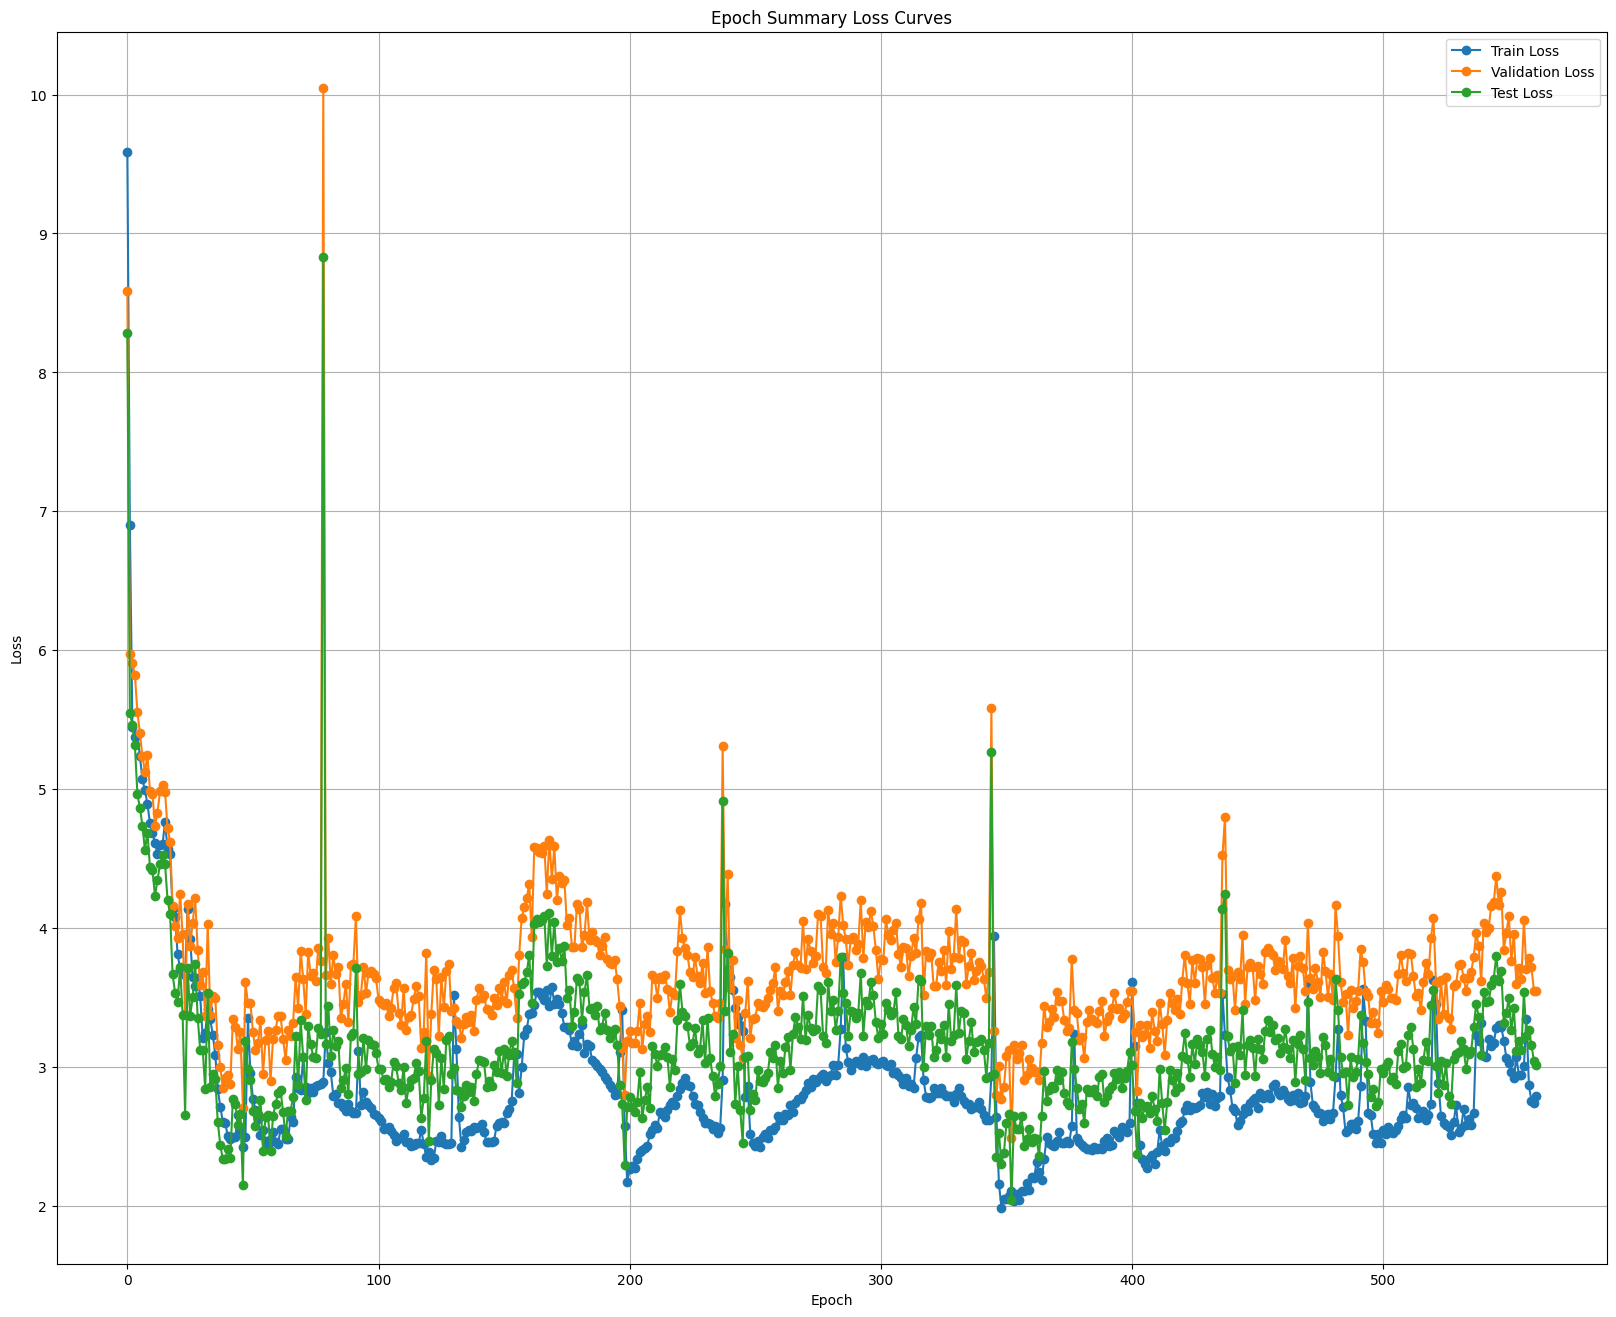

In [2]:
# Plot the epoch-level loss curves from the epoch_summary file.
plt.figure(figsize=(20,16))
plt.plot(epoch_summary['ep'], epoch_summary['Train Loss'], label='Train Loss', marker='o')
plt.plot(epoch_summary['ep'], epoch_summary['Validation Loss'], label='Validation Loss', marker='o')
plt.plot(epoch_summary['ep'], epoch_summary['Test Loss'], label='Test Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch Summary Loss Curves')
plt.legend()
plt.grid(True)
plt.show()



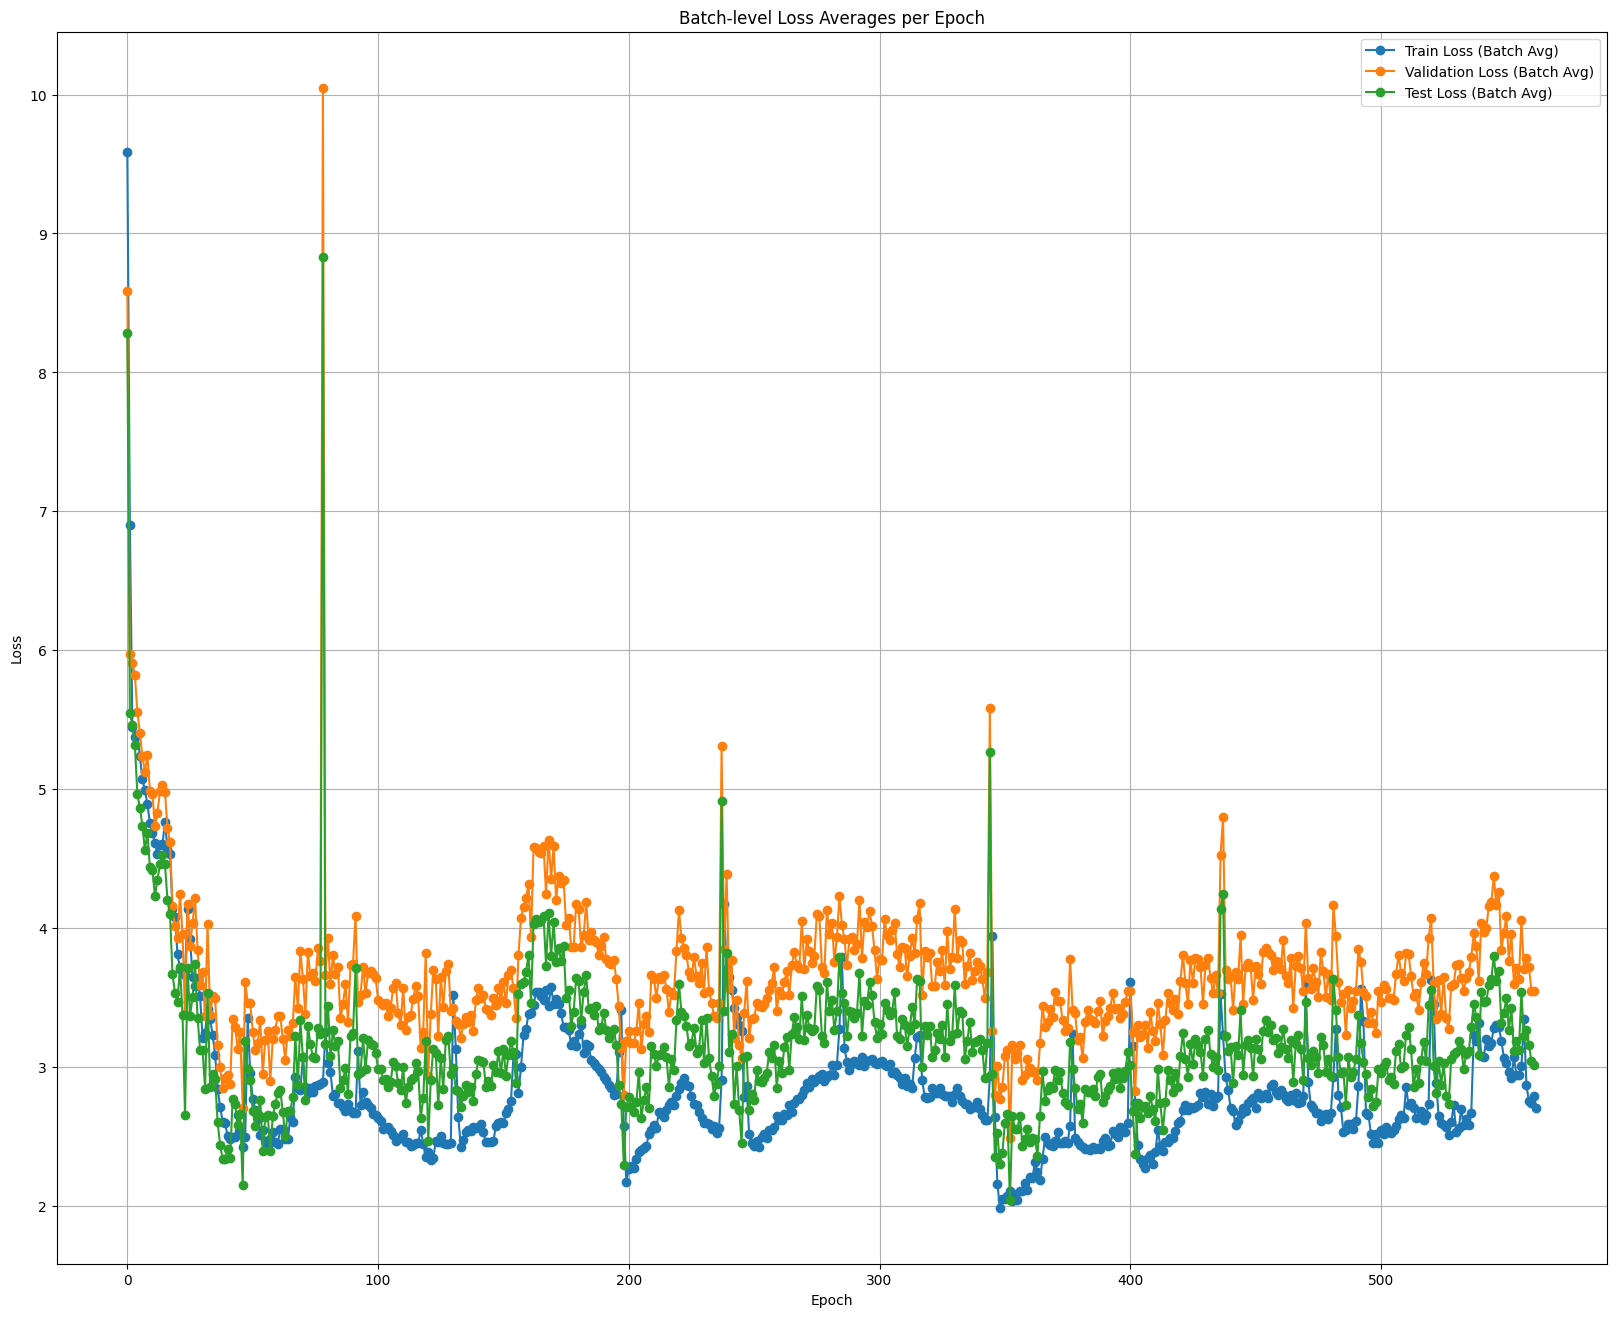

In [3]:
# Optionally, plot the batch-level loss averages (aggregated per epoch)
plt.figure(figsize=(20,16))
plt.plot(train_epoch['ep'], train_epoch['loss_all'], label='Train Loss (Batch Avg)', marker='o')
plt.plot(val_epoch['ep'], val_epoch['loss_all'], label='Validation Loss (Batch Avg)', marker='o')
plt.plot(test_epoch['ep'], test_epoch['loss_all'], label='Test Loss (Batch Avg)', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Batch-level Loss Averages per Epoch')
plt.legend()
plt.grid(True)
plt.show()



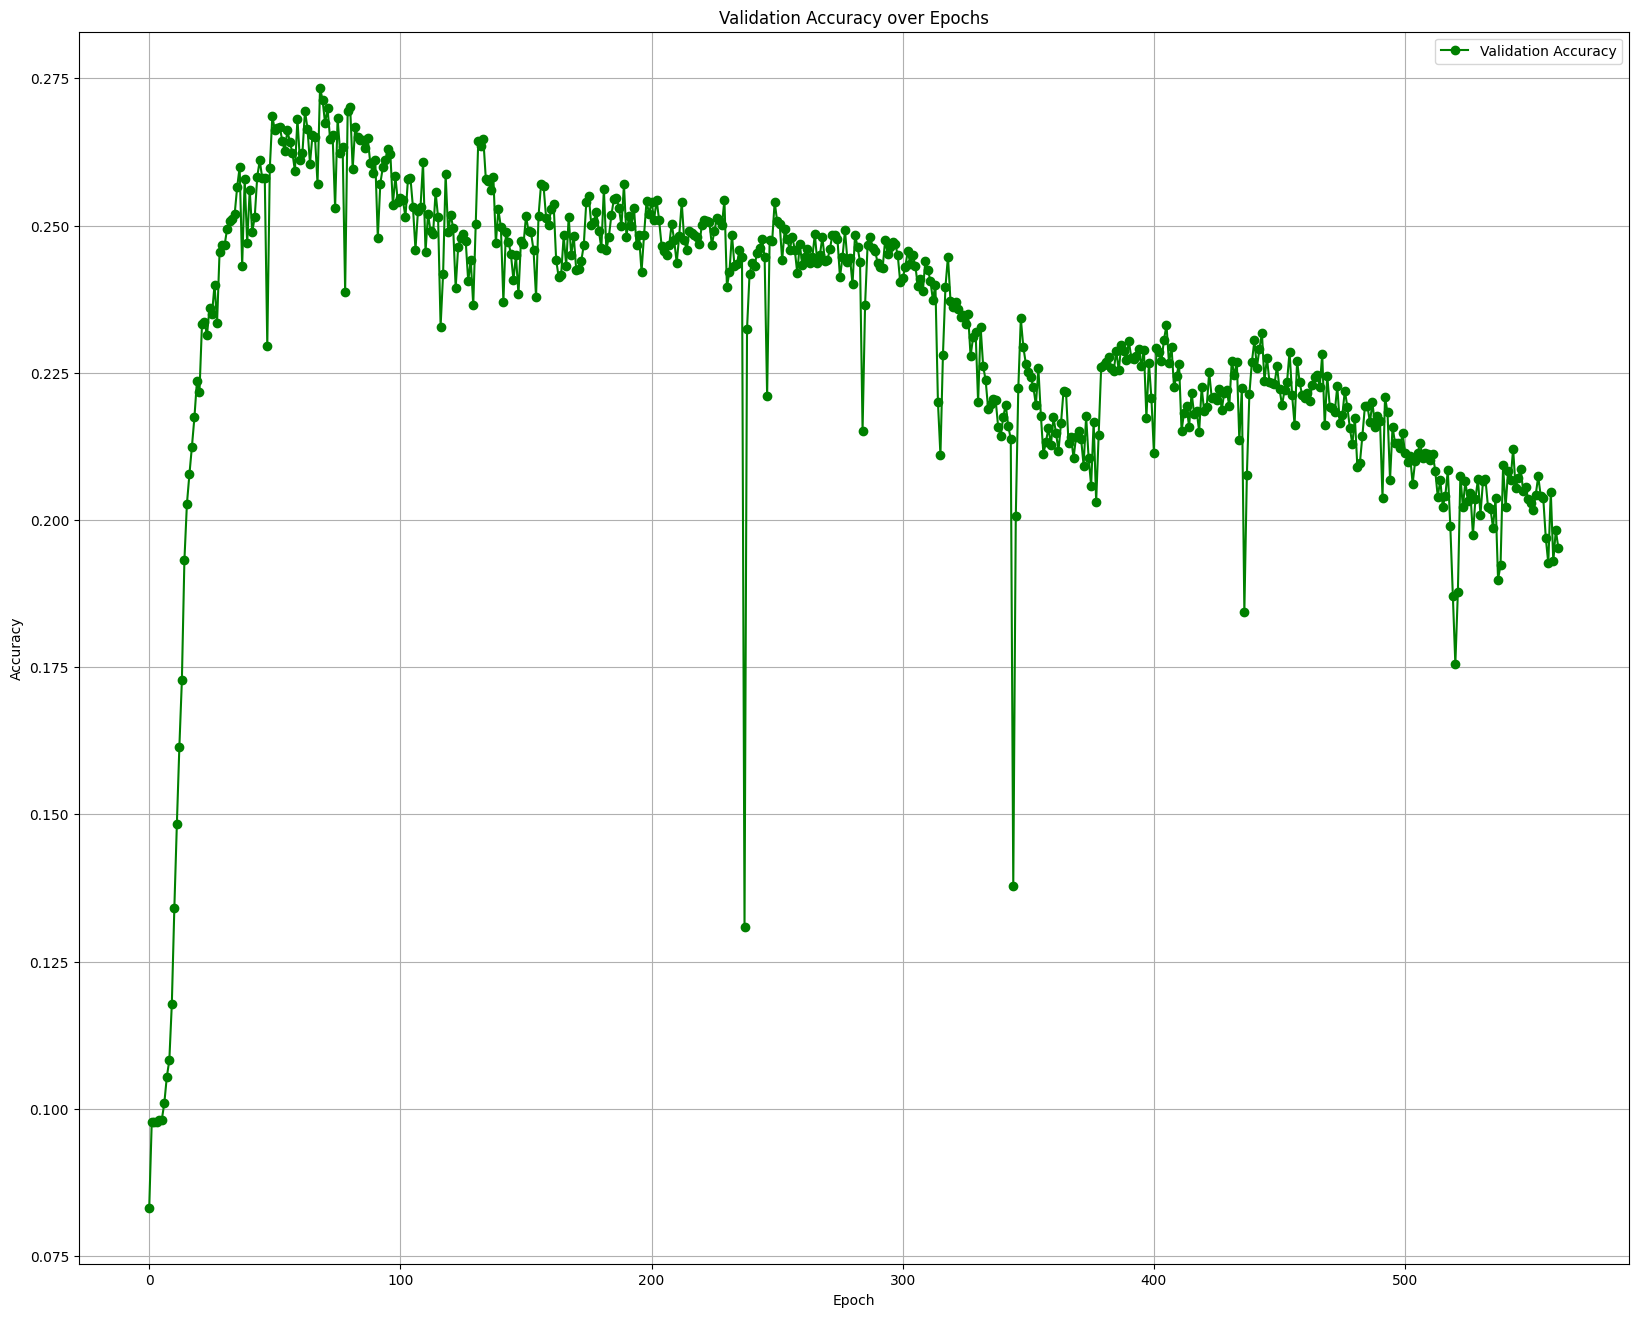

In [4]:
# For additional summary metrics (if needed), you could also plot validation accuracy, etc.
# For example, plotting validation accuracy from epoch_summary:
plt.figure(figsize=(20,16))
plt.plot(epoch_summary['ep'], epoch_summary['Val Accuracy'], label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()
